# DATASCI 503, Homework 3: Logistic Regression

Logistic regression is one of the most widely used methods for binary classification. It models the probability that an observation belongs to a particular class. In this assignment, you'll explore odds, log-odds, and the softmax generalization to multiple classes, while training classifiers and evaluating performance using ROC curves and AUC. But first, a problem about the curse of dimensionality.

---

**Problem 1:** The Curse of Dimensionality

Consider the K-nearest neighbors (KNN) algorithm where we use 10% of the available observations for each prediction. The features $X_1, X_2, \ldots, X_p$ are independently and uniformly distributed on $[0,1]$.

(a) For $p = 1$, what fraction of available observations will be used to make each prediction?

> For $p = 1$, we need to use 10% of the observations. Since we have 1 dimension, we need to use a line segment covering 10% of the range $[0,1]$, which is $0.1$ of the length. Therefore, **10% or 0.1** of the available observations will be used.

(b) For $p = 2$, what fraction of available observations will be used?

> For $p = 2$, we work in a 2-dimensional space (a flat plane), so we need to capture 10% of the **area**.
> 
> Visualize this as a unit square with side length 1 in each dimension (total area = $1 \times 1 = 1$). To capture 10% of the observations uniformly distributed in this space, we need a smaller square with area = 0.1.
> 
> If the square has side length $s$, then:
> - Area of square = $s \times s = s^2$
> - We need: $s^2 = 0.1$
> - Therefore: $s = \sqrt{0.1} \approx 0.316$
> 
> This means we use **$(0.1)^{1/2} \approx 0.316$ or about 31.6%** of the range in each dimension. So to capture just 10% of the 2D area, we must use 31.6% of each dimension's range—already much larger than the 10% needed in 1D!

(c) For $p = 100$, what fraction will be used?

> For $p = 100$, we work in a 100-dimensional space, so we need to capture 10% of the **hypervolume** (100-dimensional volume).
> 
> In 100 dimensions, a hypercube with side length $s$ has hypervolume = $s^{100}$.
> 
> To capture 10% of the observations:
> - Hypervolume = $s^{100}$
> - We need: $s^{100} = 0.1$
> - Therefore: $s = (0.1)^{1/100} \approx 0.977$
> 
> This means we use **$(0.1)^{1/100} \approx 0.977$ or about 97.7%** of the range in each dimension. To capture just 10% of the 100D hypervolume, we must use 97.7% of each dimension's range—nearly the entire space!

(d) What is the drawback of KNN when $p$ is large?

> The main drawback of KNN when $p$ is large is the **curse of dimensionality**. As the number of dimensions increases, we need to use an increasingly large fraction of the feature space (approaching 100%) just to capture a fixed percentage of observations. This means that in high dimensions, the "nearest" neighbors are no longer truly local or close to the test point. The distance between all points becomes similar, making the notion of "nearest" neighbors less meaningful, which leads to poor prediction performance.

(e) If we want to use 10% of the observations (by volume), what side length is needed for a hypercube in $p$ dimensions? Calculate for $p = 1, 2,$ and $100$.

> This question asks the same thing as parts (a), (b), and (c), but phrased differently! Since our features are uniformly distributed on [0,1], the **side length** of the hypercube (as a fraction of the unit interval) equals the **fraction of the range** used in each dimension.
> 
> **General formula:** For p dimensions, to capture 10% of observations:
> - p-dimensional volume: $s^p = 0.1$
> - Side length: $s = (0.1)^{1/p}$
> 
> **Calculations:**
> - For $p = 1$: $s = (0.1)^{1/1} = 0.1$ (10% of the range in 1D)
> - For $p = 2$: $s = (0.1)^{1/2} \approx 0.316$ (31.6% of the range in each dimension)
> - For $p = 100$: $s = (0.1)^{1/100} \approx 0.977$ (97.7% of the range in each dimension)

---

**Problem 2:** Deriving the Odds Formula

Logistic regression models the probability as:

$$
p(x) = \frac{e^{\beta_0 + \beta_1 X}}{1+ e^{\beta_0 + \beta_1 X}}
$$

Show that the odds $\frac{p(x)}{1-p(x)} = e^{\beta_0 + \beta_1 X}$.

> Starting with the logistic regression probability formula:
> $$p(x) = \frac{e^{\beta_0 + \beta_1 X}}{1+ e^{\beta_0 + \beta_1 X}}$$
>
> We can derive $1 - p(x)$:
> $$1 - p(x) = 1 - \frac{e^{\beta_0 + \beta_1 X}}{1+ e^{\beta_0 + \beta_1 X}} = \frac{1 + e^{\beta_0 + \beta_1 X} - e^{\beta_0 + \beta_1 X}}{1+ e^{\beta_0 + \beta_1 X}} = \frac{1}{1+ e^{\beta_0 + \beta_1 X}}$$
>
> Now compute the odds:
> $$\frac{p(x)}{1-p(x)} = \frac{\frac{e^{\beta_0 + \beta_1 X}}{1+ e^{\beta_0 + \beta_1 X}}}{\frac{1}{1+ e^{\beta_0 + \beta_1 X}}} = \frac{e^{\beta_0 + \beta_1 X}}{1+ e^{\beta_0 + \beta_1 X}} \cdot \frac{1+ e^{\beta_0 + \beta_1 X}}{1} = e^{\beta_0 + \beta_1 X}$$
>
> Therefore, $\frac{p(x)}{1-p(x)} = e^{\beta_0 + \beta_1 X}$ 

---

**Problem 3:** Odds and Probability Conversion

(a) If the odds of an event are 0.37, what is the probability of the event?

> If the odds = 0.37, then using the relationship $\text{odds} = \frac{p}{1-p}$:
> $$0.37 = \frac{p}{1-p}$$
> $$0.37(1-p) = p$$
> $$0.37 - 0.37p = p$$
> $$0.37 = 1.37p$$
> $$p = \frac{0.37}{1.37} \approx 0.270$$
>
> The probability is approximately **0.270 or 27.0%**.

(b) If the probability of an event is 0.16, what are the odds?

> If the probability $p = 0.16$, then:
> $$\text{odds} = \frac{p}{1-p} = \frac{0.16}{1-0.16} = \frac{0.16}{0.84} \approx 0.190$$
>
> The odds are approximately **0.190**.

---

**Problem 4:** Softmax vs Binary Logistic Regression

Consider classifying fruit as either orange or apple based on a single predictor $X$.

I fit a binary logistic regression model:
$$\log\left(\frac{p(\text{orange}|x)}{p(\text{apple}|x)}\right) = \hat{\beta}_0 + \hat{\beta}_1 X$$

with $\hat{\beta}_0 = 2$ and $\hat{\beta}_1 = -1$.

My friend fits a softmax regression model:
$$p(\text{orange}|x) = \frac{\exp(\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x)}{\exp(\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x) + \exp(\hat{\alpha}_{\text{apple},0} + \hat{\alpha}_{\text{apple},1} x)}$$

with $\hat{\alpha}_{\text{orange},0} = 1.2$, $\hat{\alpha}_{\text{orange},1} = -2$, $\hat{\alpha}_{\text{apple},0} = 3$, $\hat{\alpha}_{\text{apple},1} = 0.6$.

(a) In my model, what is $\frac{p(\text{orange}|x)}{p(\text{apple}|x)}$?

> In my model, the log-odds is $\log\left(\frac{p(\text{orange}|x)}{p(\text{apple}|x)}\right) = 2 - x$.
>
> Therefore:
> $$\frac{p(\text{orange}|x)}{p(\text{apple}|x)} = e^{2-x}$$

(b) In my friend's model, derive an expression for $\log\left(\frac{p(\text{orange}|x)}{p(\text{apple}|x)}\right)$.

> Following the softmax model:
> $$\frac{p(\text{orange}|x)}{p(\text{apple}|x)} = \frac{\frac{\exp(\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x)}{\exp(\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x) + \exp(\hat{\alpha}_{\text{apple},0} + \hat{\alpha}_{\text{apple},1} x)}}{\frac{\exp(\hat{\alpha}_{\text{apple},0} + \hat{\alpha}_{\text{apple},1} x)}{\exp(\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x) + \exp(\hat{\alpha}_{\text{apple},0} + \hat{\alpha}_{\text{apple},1} x)}}$$
>
> The denominators cancel:
> $$\frac{p(\text{orange}|x)}{p(\text{apple}|x)} = \frac{\exp(\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x)}{\exp(\hat{\alpha}_{\text{apple},0} + \hat{\alpha}_{\text{apple},1} x)}$$
>
> Taking the log:
> $$\log\left(\frac{p(\text{orange}|x)}{p(\text{apple}|x)}\right) = (\hat{\alpha}_{\text{orange},0} + \hat{\alpha}_{\text{orange},1} x) - (\hat{\alpha}_{\text{apple},0} + \hat{\alpha}_{\text{apple},1} x)$$
> $$= (\hat{\alpha}_{\text{orange},0} - \hat{\alpha}_{\text{apple},0}) + (\hat{\alpha}_{\text{orange},1} - \hat{\alpha}_{\text{apple},1})x$$

(c) Show the relationship between $\hat{\beta}_0, \hat{\beta}_1$ and my friend's $\hat{\alpha}$ coefficients.

> **The Relationship:** The binary logistic regression coefficients are always equal to the **difference** between the softmax class-specific coefficients:
> $$\hat{\beta}_0 = \hat{\alpha}_{\text{orange},0} - \hat{\alpha}_{\text{apple},0}$$
> $$\hat{\beta}_1 = \hat{\alpha}_{\text{orange},1} - \hat{\alpha}_{\text{apple},1}$$
>
> **For the specific coefficients given in the problem:**
> $$\hat{\beta}_0 = 1.2 - 3 = -1.8$$
> $$\hat{\beta}_1 = -2 - 0.6 = -2.6$$
>
> However, my model specifies $\hat{\beta}_0 = 2$ and $\hat{\beta}_1 = -1$ (which are different from -1.8 and -2.6). This means the two models with the given coefficients do **not** represent the same classifier—they will make different predictions. 
>
> **Key takeaway:** While the general relationship between binary and softmax coefficients always holds, these two particular models happen to have been fit with different coefficients, so they produce different classification boundaries.

---

**Problem 5:** Predicting Academic Success

Suppose we are predicting whether a student gets an A in a class based on hours studied ($X_1$) and GPA ($X_2$). The logistic regression model is:

$$\log\left(\frac{p}{1-p}\right) = -4 + 0.05 X_1 + X_2$$

(a) A student with a GPA of 3.5 studies 5 hours per week. What is the probability they get an A?

> Given: $\log\left(\frac{p}{1-p}\right) = -4 + 0.05 X_1 + X_2$
>
> For a student with GPA = 3.5 and studying 5 hours/week:
> $$\log\left(\frac{p}{1-p}\right) = -4 + 0.05(5) + 3.5 = -4 + 0.25 + 3.5 = -0.25$$
>
> Therefore:
> $$\frac{p}{1-p} = e^{-0.25} \approx 0.7788$$
>
> **Solving for p** by cross-multiplying:
> $$p = e^{-0.25}(1-p)$$
> $$p = e^{-0.25} - e^{-0.25}p$$
> $$p + e^{-0.25}p = e^{-0.25}$$
> $$p(1 + e^{-0.25}) = e^{-0.25}$$
> $$p = \frac{e^{-0.25}}{1 + e^{-0.25}} = \frac{1}{1 + e^{0.25}} \approx \frac{1}{1.2840} \approx 0.438$$
>
> The probability is approximately **0.438 or 43.8%**.

(b) What are the odds this student gets an A?

> From part (a), we found that $\frac{p}{1-p} = e^{-0.25} \approx 0.7788$.
>
> The odds are approximately **0.779**.

(c) How many hours would this student need to study to have a 50% chance of getting an A?

> For a 50% chance, we need $p = 0.5$, which means the log-odds = 0:
> $$\log\left(\frac{0.5}{1-0.5}\right) = 0 = -4 + 0.05 X_1 + 3.5$$
> $$0 = -4 + 0.05 X_1 + 3.5$$
> $$0 = -0.5 + 0.05 X_1$$
> $$0.5 = 0.05 X_1$$
> $$X_1 = \frac{0.5}{0.05} = 10$$
>
> The student would need to study **10 hours per week** to have a 50% chance of getting an A.

## Applied Problems: College Classification

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model
import sklearn.metrics

%matplotlib inline

In [3]:
college_train = pd.read_csv("./data/college_train.csv")
college_test = pd.read_csv("./data/college_test.csv")

In [4]:
X_train = college_train.drop(["Private", "Name"], axis=1) # remove cols
Y_train = np.where(college_train["Private"] == "Yes", 1, 0) # binary response
X_test = college_test.drop(["Private", "Name"], axis=1)
Y_test = np.where(college_test["Private"] == "Yes", 1, 0)

---

**Problem 6:** Training a Classifier

Train a logistic regression model to classify colleges as Private or Public using the provided training data. Store the trained model in a variable called `model_log`.

**Hint:** Use [`sklearn.linear_model.LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). You may need to increase `max_iter` for convergence.

In [5]:
model_log = sklearn.linear_model.LogisticRegression(max_iter=100000)
model_log.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
# Test assertions
assert model_log is not None, "model_log should be defined"
assert hasattr(model_log, "predict"), "model_log should have a predict method"
assert hasattr(model_log, "predict_proba"), "model_log should have a predict_proba method"
print("All tests passed!")

All tests passed!


---

**Problem 7:** Negative Log-Likelihood

Compute the mean negative log-likelihood (NLL) on the test set. Store the predicted probabilities in a variable called `y_pred_prob` and the mean NLL in a variable called `mean_nll`.

**Hint:** Use `model_log.predict_proba()` to get probabilities and [`sklearn.metrics.log_loss()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html) to compute NLL.

In [7]:
y_pred_prob = model_log.predict_proba(X_test)
mean_nll = sklearn.metrics.log_loss(Y_test, y_pred_prob)

In [8]:
# Test assertions
assert y_pred_prob is not None, "y_pred_prob should be defined"
assert y_pred_prob.shape == (len(Y_test), 2), "y_pred_prob should have shape (n_samples, 2)"
assert mean_nll is not None, "mean_nll should be defined"
assert 0 < mean_nll < 1, "mean_nll should be between 0 and 1 for a reasonable model"
print("All tests passed!")

All tests passed!


---

**Problem 8:** Classification Metrics

Using a threshold of 0.5, compute the following classification metrics:
- True Positive Rate (TPR, also called Recall or Sensitivity)
- False Positive Rate (FPR)
- True Negative Rate (TNR, also called Specificity)
- False Negative Rate (FNR)

Store these in variables `tpr`, `fpr`, `tnr`, and `fnr` respectively.

**Hint:** You can use [`sklearn.metrics.confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) to extract the counts needed for these calculations.

In [9]:
# Get predictions using 0.5 threshold 
y_pred = (y_pred_prob[:, 1] >= 0.5).astype(int)

# Get confusion matrix 
cm = sklearn.metrics.confusion_matrix(Y_test, y_pred)
tn, fp, fn, tp = cm.ravel() # flatten multidimensional array into 1D

# Calculate metrics 
tpr = tp / (tp + fn) 
fpr = fp / (fp + tn) 
tnr = tn / (tn + fp) 
fnr = fn / (fn + tp)

In [10]:
# Test assertions
assert 0 <= tpr <= 1, "TPR should be between 0 and 1"
assert 0 <= fpr <= 1, "FPR should be between 0 and 1"
assert 0 <= tnr <= 1, "TNR should be between 0 and 1"
assert 0 <= fnr <= 1, "FNR should be between 0 and 1"
assert np.isclose(tpr + fnr, 1.0), "TPR + FNR should equal 1"
assert np.isclose(fpr + tnr, 1.0), "FPR + TNR should equal 1"
print("All tests passed!")

All tests passed!


---

**Problem 9:** Threshold Tradeoffs

(a) Repeat the classification metrics computation using a threshold of 0.9. Store the results in variables called `tpr_high`, `fpr_high`, `tnr_high`, and `fnr_high`.

In [11]:
# Get predictions using 0.9 threshold
y_pred_high = (y_pred_prob[:, 1] >= 0.9).astype(int)

# Get confusion matrix
cm_high = sklearn.metrics.confusion_matrix(Y_test, y_pred_high)
tn_high, fp_high, fn_high, tp_high = cm_high.ravel()

# Calculate metrics
tpr_high = tp_high / (tp_high + fn_high)
fpr_high = fp_high / (fp_high + tn_high)
tnr_high = tn_high / (tn_high + fp_high)
fnr_high = fn_high / (fn_high + tp_high)

In [12]:
# Test assertions
assert 0 <= tpr_high <= 1, "TPR should be between 0 and 1"
assert 0 <= fpr_high <= 1, "FPR should be between 0 and 1"
assert np.isclose(tpr_high + fnr_high, 1.0), "TPR + FNR should equal 1"
assert np.isclose(fpr_high + tnr_high, 1.0), "FPR + TNR should equal 1"
print("All tests passed!")

All tests passed!


In [13]:
print("Threshold = 0.5")
print("Confusion Matrix:")
print(cm)
print(f"TPR: {tpr:.4f}, FPR: {fpr:.4f}, TNR: {tnr:.4f}, FNR: {fnr:.4f}")

print("\nThreshold = 0.9")
print("Confusion Matrix:")
print(cm_high)
print(f"TPR: {tpr_high:.4f}, FPR: {fpr_high:.4f}, TNR: {tnr_high:.4f}, FNR: {fnr_high:.4f}")

Threshold = 0.5
Confusion Matrix:
[[32  1]
 [ 5 89]]
TPR: 0.9468, FPR: 0.0303, TNR: 0.9697, FNR: 0.0532

Threshold = 0.9
Confusion Matrix:
[[32  1]
 [21 73]]
TPR: 0.7766, FPR: 0.0303, TNR: 0.9697, FNR: 0.2234


(b) Based on your results above, explain what happens to TPR and FPR when we increase the threshold from 0.5 to 0.9.
> When we increase the threshold from 0.5 to 0.9:
> 
> - **TPR decreases** (0.9468 → 0.7766): The classifier becomes more conservative, missing 16 additional actual positive cases (TP: 89 → 73, FN: 5 → 21).
> 
> - **FPR remains constant** (0.0303): Both FP and TN stay the same, so specificity doesn't improve.
> 
> - **Key insight**: Increasing the threshold reduces **TPR** (from 0.9468 to 0.7766) but does **not** reduce **FPR** (stays at 0.0303). This is a poor threshold tradeoff for this dataset—we sacrifice true positive rate without gaining any improvement in false positive rate.

---

**Problem 10:** ROC Curve

Plot the ROC (Receiver Operating Characteristic) curve by varying the threshold from 0 to 1. Store the lists of FPR and TPR values across thresholds in variables called `fpr_list` and `tpr_list`.

**Hint:** Create thresholds using `np.arange(0, 1.001, 0.01)` and compute TPR/FPR at each threshold. Use [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) with `zero_division=0` to handle edge cases.

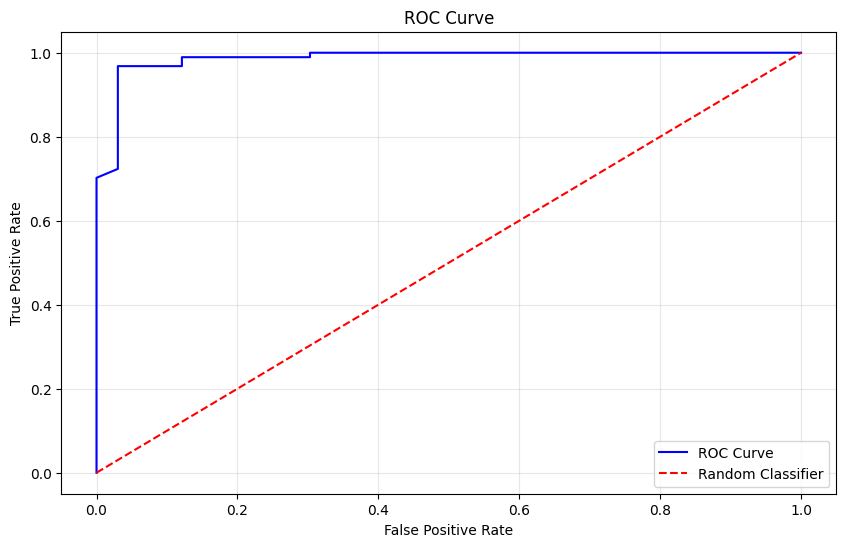

In [16]:
# Create thresholds 
thresholds = np.arange(0, 1.001, 0.01) # evenly spaced from 0-1

fpr_list = []
tpr_list = []

# Calculate TPR and FPR at each threshold 
for threshold in thresholds: 
    y_pred_threshold = (y_pred_prob[:, 1] >= threshold).astype(int)

    # Calcualte TPR (recall) ; set value to return when there is zero division 
    tpr_val = sklearn.metrics.recall_score(Y_test, y_pred_threshold, zero_division=0)

    # Calculate FPR 
    cm_temp = sklearn.metrics.confusion_matrix(Y_test, y_pred_threshold) 
    tn_temp, fp_temp, fn_temp, tp_temp = cm_temp.ravel() 
        # handle zero division error; classifier could predict no positive cases with high thresholds 
    fpr_val = fp_temp / (fp_temp + tn_temp) if (fp_temp + tn_temp) > 0 else 0 

    tpr_list.append(tpr_val) 
    fpr_list.append(fpr_val)

# Plot ROC cuve 
plt.figure(figsize=(10,6))
plt.plot(fpr_list, tpr_list, 'b-', label = "ROC Curve")
plt.plot([0,1], [0,1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()


In [17]:
# Test assertions
assert len(fpr_list) > 0, "fpr_list should not be empty"
assert len(tpr_list) > 0, "tpr_list should not be empty"
assert len(fpr_list) == len(tpr_list), "fpr_list and tpr_list should have same length"
assert all(0 <= x <= 1 for x in fpr_list), "All FPR values should be between 0 and 1"
assert all(0 <= x <= 1 for x in tpr_list), "All TPR values should be between 0 and 1"
print("All tests passed!")

All tests passed!


---

**Problem 11:** AUC Score

Compute the Area Under the ROC Curve (AUC) score. Store the result in a variable called `auc_score`.

**Hint:** Use [`sklearn.metrics.roc_auc_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html).

In [21]:
auc_score = sklearn.metrics.roc_auc_score(Y_test, y_pred_prob[:,1])
print(auc_score)

0.9867827208252742


In [22]:
# Test assertions
assert auc_score is not None, "auc_score should be defined"
assert 0 <= auc_score <= 1, "AUC should be between 0 and 1"
assert auc_score > 0.5, "AUC should be greater than 0.5 (better than random)"
print("All tests passed!")

All tests passed!
